In [1]:
import numpy
import math
import pandas
import poisson_utils as utils

In [2]:
centroid_frame = pandas.read_csv(r"C:\Users\harsh\Documents\thesis\poisson\centroid_locations.csv")
X, Y = centroid_frame["cen_X"].to_numpy(), centroid_frame["cen_Y"].to_numpy()

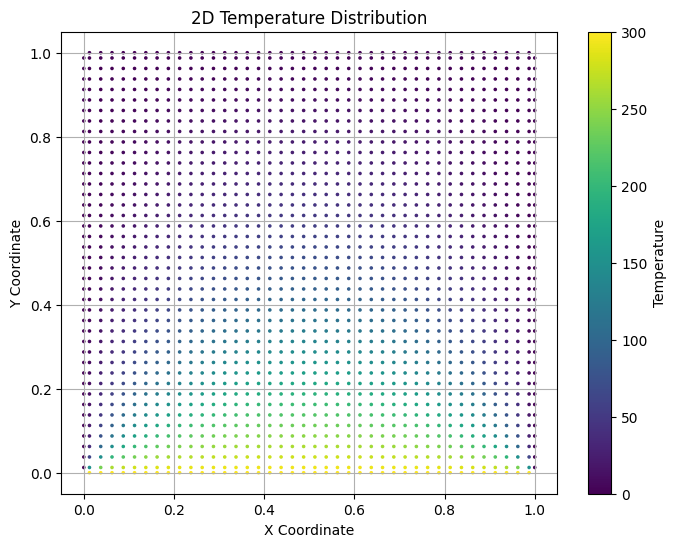

In [3]:
a = 1
b = 1
BC = [0, 0, 300, 0]  #BC = [x_min, x_max, y_min, y_max]
final_T = utils.XY_steady_state_temperature(X, Y, a, b, BC)
utils.plot_temperature(final_T= final_T)

In [4]:
#df = pandas.DataFrame(final_T, columns= ["X", "Y", "Temperature (K)"])
#df.to_csv(r"D:\thesis\python\steady_centroid_temperatures.csv", sep= ",", index= False)

In [5]:
dir = r'C:\Users\harsh\Documents\thesis\poisson'
range_var = [0.2, 0.1, 0.05, 0.025, 0.0125]
output_data = utils.return_outputframe_list(dir, '_.csv', range_var, 'centroid_output_baseSize_')

In [6]:
L2_data = []
L_inf_data = []
for data in output_data:
    [base_size, out_X, out_Y, out_T, el_vol] = [
        data['range_var'],
        data['x_coords'],
        data['y_coords'],
        data['numerical_T'],
        data['elem_volume']
    ]
    steady_state_data = [a, b, BC]
    L_inf, L2_err = utils.return_L_errors(out_X, out_Y, out_T, el_vol, steady_state_data)
    print('base size: ', base_size)
    print('L2: ', L2_err)
    print('L_inf: ', L_inf)
    print('---------------')
    L2_data.append([len(el_vol), L2_err])
    L_inf_data.append([len(el_vol), L_inf])
    

base size:  0.2
L2:  0.32696751998337914
L_inf:  6.9241152299275655
---------------
base size:  0.1
L2:  0.1270921795744553
L_inf:  6.612872683458193
---------------
base size:  0.05
L2:  0.03428212575476039
L_inf:  6.580288597036855
---------------
base size:  0.025
L2:  0.008951567666121561
L_inf:  6.579454909568938
---------------
base size:  0.0125
L2:  0.0022736298740338797
L_inf:  6.5782082908411965
---------------


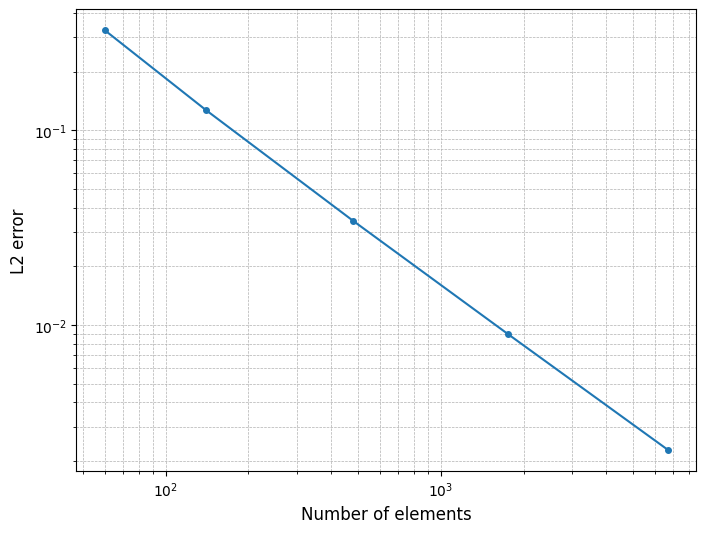

In [11]:
utils.plot_error_data(L2_data, log_bool = True)

In [8]:
#output_frame = pandas.read_csv(r"C:\Users\harsh\Documents\thesis\poisson\poisson_centroid_output.csv")
#df2 = pandas.read_csv(r"D:\thesis\python\2D_SteadyState_HeatEquation.csv")
#[out_X, out_Y, out_T, interpolated_T, num_L_inf, num_L2, el_vol] = [
#    output_frame["X (m)"].to_numpy(), 
#    output_frame["Y (m)"].to_numpy(), 
#    output_frame["Temperature (K)"].to_numpy(), 
#    output_frame["steady_table_vals"].to_numpy(),
#    output_frame["L_inf (K)"].to_numpy(),
#    output_frame["L2_err"].to_numpy(),
#    output_frame["Volume (m^3)"].to_numpy()]


In [9]:
#steady_state_data = [a, b, BC]
#L1, L2 = utils.return_L_errors(out_X, out_Y, out_T, el_vol, steady_state_data)

In [10]:
#reported_L2 = 0
#for L2, vol in zip(num_L2, el_vol):
#    reported_L2 += L2*vol
#reported_L2_err = numpy.sqrt(reported_L2/len(num_L2))
#print('reported L2: ', reported_L2_err)
#print('reported L_inf: ', max(num_L_inf))

    